# Atelier — Préparation de données tabulaires

---
# Partie 1 — Exploration des données

### 1) Chargement du dataset

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/smart_building_raw.csv")
print("Fichier chargé :", df.shape)

Fichier chargé : (507, 14)


### 2) Premières lignes

In [4]:
print(df.head())

   id_mesure                 date batiment      type_batiment zone  \
0       1174  2025-02-13 06:00:00       B8           Entrepôt    A   
1       1275  2025-03-10 12:00:00       B7             Bureau    D   
2       1493  2025-05-04 00:00:00       B5  Centre commercial    B   
3       1073  2025-01-19 00:00:00       B6         Université    D   
4       1454  2025-04-24 06:00:00       B7             Bureau    D   

   temperature  humidite     co2  occupation  consommation_kwh  \
0         23.0      40.0   851.0        26.0             138.4   
1         28.0      69.0   538.0         0.0             170.2   
2         19.5      52.3  1198.0        64.0             149.8   
3         20.0      58.4  1014.0        30.0             141.6   
4         26.8      70.5   628.0        42.0             228.3   

  mode_climatisation etat_systeme jour_semaine alerte  
0                Eco       Normal        Jeudi    Non  
1                Eco       Normal        Lundi    Non  
2             

### 3) Dernières lignes

In [5]:
print(df.tail())

     id_mesure                 date batiment      type_batiment zone  \
502       1107  2025-01-27 12:00:00       B2              École    C   
503       1271  2025-03-09 12:00:00       B3            Hôpital    B   
504       1349  2025-03-29 00:00:00       B5  Centre commercial    B   
505       1436  2025-04-19 18:00:00       B7             Bureau    C   
506       1103  2025-01-26 12:00:00       B2              École    D   

     temperature  humidite     co2  occupation  consommation_kwh  \
502         29.8      66.5   778.0        48.0             243.5   
503         21.1      66.3  3900.0        53.0             145.8   
504         21.6      61.9   959.0        33.0             100.2   
505         21.2      54.5  1066.0        38.0             150.9   
506          NaN      64.8   584.0        29.0             163.4   

    mode_climatisation etat_systeme jour_semaine alerte  
502             Normal       Normal        Lundi    Non  
503                Eco       Alerte     Di

### 4) Nombre d'observations

In [6]:
print("Nombre d'observations :", df.shape[0])

Nombre d'observations : 507


### 5) Nombre de variables

In [7]:
print("Nombre de variables :", df.shape[1])

Nombre de variables : 14


### 6) Identifier les variables numériques

In [8]:
variables_numeriques = df.select_dtypes(include="number").columns.tolist()
print("Variables numériques :", variables_numeriques)

Variables numériques : ['id_mesure', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh']


### 7) Identifier les variables catégorielles

In [10]:
variables_categorielles = df.select_dtypes(include=["object", "str", "category"]).columns.tolist()
print("Variables catégorielles :", variables_categorielles)

Variables catégorielles : ['date', 'batiment', 'type_batiment', 'zone', 'mode_climatisation', 'etat_systeme', 'jour_semaine', 'alerte']


### 8) Identifier les dates

In [23]:
n_dates_before = df["date"].shape[0]
df["date"] = pd.to_datetime(df["date"], errors="coerce")
n_dates_invalid = df["date"].isna().sum()

print(f"Nombre de dates invalides : {n_dates_invalid} sur {n_dates_before}")
print("Variables de dates :", df["date"])

Nombre de dates invalides : 5 sur 507
Variables de dates : 0     2025-02-13 06:00:00
1     2025-03-10 12:00:00
2     2025-05-04 00:00:00
3     2025-01-19 00:00:00
4     2025-04-24 06:00:00
              ...        
502   2025-01-27 12:00:00
503   2025-03-09 12:00:00
504   2025-03-29 00:00:00
505   2025-04-19 18:00:00
506   2025-01-26 12:00:00
Name: date, Length: 507, dtype: datetime64[us]


### 9) Variables identifiantes

In [28]:
identifiants = ["id_mesure"]
print("Variable(s) identifiant(s) :", identifiants)
print("Nombre de valeurs uniques dans id_mesure :", df["id_mesure"].nunique(), "sur", len(df))

Variable(s) identifiant(s) : ['id_mesure']
Nombre de valeurs uniques dans id_mesure : 500 sur 507


### 10) Déterminer les statistiques : moyenne, médiane, minimum, maximum, écart-type et quartiles.

In [29]:
stats_numeriques = df[variables_numeriques].describe().T
stats_numeriques["median"] = df[variables_numeriques].median()
stats_numeriques

,count,mean,std,min,25%,50%,75%,max,median
id_mesure,507.0,1251.114398,144.782769,1001.0,1125.500,1252.00,1376.500,1500.0,1252.00
temperature,495.0,24.154141,7.418465,-30.0,21.600,24.00,26.000,96.0,24.00
humidite,496.0,57.864113,16.026336,-12.0,49.275,57.55,65.750,160.0,57.55
co2,500.0,844.150000,582.181386,89.0,623.750,787.50,952.000,6000.0,787.50
occupation,501.0,44.850299,24.949139,-20.0,27.000,46.00,61.000,116.0,46.00
consommation_kwh,502.0,169.069323,53.164294,-100.0,136.875,169.80,202.975,336.2,169.80


### 11)Y a-t-il des variables potentiellement problématiques ?

On croise un premier coup d'œil sur les valeurs manquantes, les valeurs extrêmes (min/max issus de la question précédente) et le nombre de catégories par variable catégorielle pour repérer les variables suspectes.

In [33]:
print("=== Valeurs manquantes par colonne ===")
print(df.isna().sum())

print("\n=== Étendue (min/max) des variables numériques ===")
print(df[variables_numeriques].agg(["min", "max"]).T)


=== Valeurs manquantes par colonne ===
id_mesure              0
date                   0
batiment               0
type_batiment          4
zone                   0
temperature           12
humidite              11
co2                    7
occupation             6
consommation_kwh       5
mode_climatisation     5
etat_systeme           0
jour_semaine           5
alerte                 0
dtype: int64

=== Étendue (min/max) des variables numériques ===
                     min     max
id_mesure         1001.0  1500.0
temperature        -30.0    96.0
humidite           -12.0   160.0
co2                 89.0  6000.0
occupation         -20.0   116.0
consommation_kwh  -100.0   336.2


### 12)Détecter et corriger les données incohérentes

In [43]:
df_clean = df.copy()

# a) humidité < 0
mask_humidite_neg = df_clean["humidite"] < 0
print("a) humidité < 0 :", mask_humidite_neg.sum(), "valeurs")

# b) humidité > 100
mask_humidite_sup = df_clean["humidite"] > 100
print("b) humidité > 100 :", mask_humidite_sup.sum(), "valeurs")

# c) température extrêmement élevée (ou extrêmement basse, tout aussi impossible pour un bâtiment)
# on définit une plage physiquement plausible pour une température intérieure/extérieure de bâtiment
mask_temp_extreme = (df_clean["temperature"] > 45) | (df_clean["temperature"] < -10)
print("c) température extrême (hors [-10, 45] °C) :", mask_temp_extreme.sum(), "valeurs")

# d) valeurs négatives -> occupation ne peut pas être négative (nombre de personnes)
mask_occupation_neg = df_clean["occupation"] < 0
print("d) occupation négative :", mask_occupation_neg.sum(), "valeurs")

# e) consommation négative -> une consommation énergétique ne peut pas être négative
mask_conso_neg = df_clean["consommation_kwh"] < 0
print("e) consommation négative :", mask_conso_neg.sum(), "valeurs")

a) humidité < 0 : 3 valeurs
b) humidité > 100 : 7 valeurs
c) température extrême (hors [-10, 45] °C) : 6 valeurs
d) occupation négative : 5 valeurs
e) consommation négative : 4 valeurs


##### f) Ces valeurs sont manifestement erronées et on ne peut pas retrouver leur vraie valeur

In [45]:
#on les transforme en valeurs manquantes (NaN)
df_clean.loc[mask_humidite_neg | mask_humidite_sup, "humidite"] = np.nan
df_clean.loc[mask_temp_extreme, "temperature"] = np.nan
df_clean.loc[mask_occupation_neg, "occupation"] = np.nan
df_clean.loc[mask_conso_neg, "consommation_kwh"] = np.nan

print("f) Valeurs incohérentes transformées en NaN.")
print(df_clean[["humidite", "temperature", "occupation", "consommation_kwh"]].isna().sum())

f) Valeurs incohérentes transformées en NaN.
humidite            21
temperature         18
occupation          11
consommation_kwh     9
dtype: int64


##### g) Recherche de catégories mal orthographiées 

In [48]:
for c in ["type_batiment", "mode_climatisation"]:
    print(f"--- {c} ---")
    print(sorted(df_clean[c].dropna().unique().tolist()))
    print()

--- type_batiment ---
[' Bureau ', ' UNIVERSITÉ', 'BUREAU', 'Bureau', 'Bureu', 'Centre commercial', 'Entrepôt', 'Hôpital', 'Université', 'bureau', 'centre commercial', 'ecole', 'entrepot', 'hôpital ', 'ÉCOLE', 'École']

--- mode_climatisation ---
['BOOST', 'Boost', 'Eco', 'Normal', 'Normal ', 'normal', 'normale']



##### h) Normalisation : suppression des espaces puis uniformisation de la casse,puis correction des fautes de frappe restantes vers une catégorie canonique

In [ ]:
import os

# Étape 1 : strip + lower pour toutes les colonnes textuelles catégorielles
# (on reste en dtype "object" : le nettoyage pandas .str gère nativement les NaN existants
#  sans les transformer en pd.NA, ce qui évite des soucis de compatibilité avec scikit-learn)
for c in ["batiment", "type_batiment", "zone", "mode_climatisation", "etat_systeme",
          "jour_semaine", "alerte"]:
    df_clean[c] = df_clean[c].str.strip().str.lower()

# Étape 2 : dictionnaires de correction (fautes de frappe -> catégorie canonique)
mapping_type_batiment = {
    "entrepot": "Entrepôt", "entrepôt": "Entrepôt",
    "bureau": "Bureau", "bureu": "Bureau",
    "centre commercial": "Centre commercial",
    "université": "Université", "universite": "Université",
    "hôpital": "Hôpital", "hopital": "Hôpital",
    "ecole": "École", "école": "École",
}
mapping_mode_clim = {
    "eco": "Eco",
    "normal": "Normal", "normale": "Normal",
    "boost": "Boost",
}

df_clean["type_batiment"] = df_clean["type_batiment"].map(mapping_type_batiment)
df_clean["mode_climatisation"] = df_clean["mode_climatisation"].map(mapping_mode_clim)

# Les autres colonnes catégorielles sont remises en casse "Titre" pour la lisibilité
df_clean["etat_systeme"] = df_clean["etat_systeme"].str.capitalize()
df_clean["jour_semaine"] = df_clean["jour_semaine"].str.capitalize()
df_clean["alerte"] = df_clean["alerte"].str.capitalize()

print("Catégories après normalisation :")
for c in ["batiment", "type_batiment", "zone", "mode_climatisation", "etat_systeme",
          "jour_semaine", "alerte"]:
    print(f"{c} : {sorted(df_clean[c].dropna().unique().tolist())}")

df_clean.to_csv(os.path.join("../exports/", "01_incoherences_corrigees.csv"), index=False)
print("\nExport intermédiaire -> exports/01_incoherences_corrigees.csv")

Catégories après normalisation :
batiment : ['b1', 'b2', 'b3', 'b4', 'b5', 'b6', 'b7', 'b8']
type_batiment : ['Bureau', 'Centre commercial', 'Entrepôt', 'Hôpital', 'Université', 'École']
zone : ['a', 'b', 'c', 'd']
mode_climatisation : ['Boost', 'Eco', 'Normal']
etat_systeme : ['Alerte', 'Normal', 'Panne']
jour_semaine : ['Dimanche', 'Jeudi', 'Lundi', 'Mardi', 'Mercredi', 'Samedi', 'Vendredi']
alerte : ['Non', 'Oui']

Export intermédiaire -> exports/01_incoherences_corrigees.csv


#### 13) Pour les valeurs manquantes
##### a) Calculer le nombre et le pourcentage de valeurs manquantes par colonne

In [52]:
# a) Nombre et pourcentage de valeurs manquantes par colonne
nb_manquants = df_clean.isna().sum()
pct_manquants = (df_clean.isna().mean() * 100).round(2)
missing_report = pd.DataFrame({"nb_manquants": nb_manquants, "pourcentage_manquants": pct_manquants})
missing_report = missing_report[missing_report["nb_manquants"] > 0].sort_values(
    "pourcentage_manquants", ascending=False)
missing_report

,nb_manquants,pourcentage_manquants
humidite,21,4.14
temperature,18,3.55
occupation,11,2.17
consommation_kwh,9,1.78
co2,7,1.38
mode_climatisation,5,0.99
jour_semaine,5,0.99
type_batiment,4,0.79


##### b) Quelle variable possède le plus de valeurs manquantes ?

In [53]:
variable_plus_manquante = missing_report.index[0]
print(f"b) Variable avec le plus de valeurs manquantes : '{variable_plus_manquante}' "
      f"({missing_report.iloc[0]['pourcentage_manquants']} %)")

b) Variable avec le plus de valeurs manquantes : 'humidite' (4.14 %)


#### c) Quelle stratégie utiliser pour les valeurs manquantes ?

Une imputation ciblée par type de variable : médiane pour les variables numériques (robuste aux valeurs extrêmes déjà repérées en Question 12), mode (valeur la plus fréquente) pour les variables catégorielles. 

##### d) Peut-on supprimer toutes les lignes contenant des valeurs manquantes ?

Non, ou en tout cas pas systématiquement. Le pourcentage de valeurs manquantes reste
faible par colonne, mais un dropna() global supprimerait toutes les lignes ayant AU MOINS
une valeur manquante sur N'IMPORTE QUELLE colonne, ce qui ferait perdre une part importante
et potentiellement biaisée des observations (voir calcul ci-dessous).


In [54]:
lignes_avant = len(df_clean)
lignes_sans_na = len(df_clean.dropna())
print(f"Lignes totales : {lignes_avant}")
print(f"Lignes restantes après dropna() global : {lignes_sans_na}")
print(f"Lignes perdues : {lignes_avant - lignes_sans_na} ")

Lignes totales : 507
Lignes restantes après dropna() global : 434
Lignes perdues : 73 


##### e) Dans quels cas utiliser la moyenne ?

Quand la variable suit une distribution à peu près symétrique et sans valeurs aberrantes
marquées : la moyenne est alors représentative de la tendance centrale.

##### f) Quand préférer la médiane ?

Quand la distribution est asymétrique ou contient des valeurs extrêmes (outliers) :
la médiane, contrairement à la moyenne, n'est pas sensible à ces valeurs extrêmes.

##### g) Comment traiter une variable catégorielle ?

En imputant par le mode (la catégorie la plus fréquente), ou en créant une catégorie explicite 'Inconnu'/'Manquant' si l'absence de valeur peut avoir un sens en soi.

#### 14) Détecter et traiter les doublons

##### a) Identifier les doublons

In [56]:
#Identifier les doublons (lignes strictement identiques sur toutes les colonnes)
duplicated_mask = df_clean.duplicated(keep=False)
print(f"Nombre de lignes impliquées dans un doublon : {duplicated_mask.sum()}")

Nombre de lignes impliquées dans un doublon : 14


##### b) Afficher les doublons

In [57]:
doublons = df_clean[duplicated_mask].sort_values(list(df_clean.columns))
doublons

,id_mesure,date,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,etat_systeme,jour_semaine,alerte
117,1026,2025-01-07 06:00:00,b6,Bureau,a,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
192,1026,2025-01-07 06:00:00,b6,Bureau,a,23.0,74.3,952.0,89.0,247.6,Normal,Normal,Mardi,Oui
9,1118,2025-01-30 06:00:00,b1,Bureau,a,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
123,1118,2025-01-30 06:00:00,b1,Bureau,a,22.0,NaN,479.0,64.0,145.0,Normal,Normal,Jeudi,Non
23,1264,2025-03-07 18:00:00,b1,Bureau,b,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
434,1264,2025-03-07 18:00:00,b1,Bureau,b,21.1,38.3,1034.0,74.0,199.2,Normal,Panne,Vendredi,Oui
455,1320,2025-03-21 18:00:00,b7,Bureau,b,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
464,1320,2025-03-21 18:00:00,b7,Bureau,b,27.5,27.2,359.0,33.0,185.8,Normal,Normal,Vendredi,Non
238,1402,2025-04-11 06:00:00,b2,École,a,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non
418,1402,2025-04-11 06:00:00,b2,École,a,22.6,44.0,868.0,62.0,172.5,Eco,Normal,Vendredi,Non


##### c) Sont-ils réellement identiques ? 

In [59]:
#on vérifie via duplicated() strict (toutes colonnes)
nb_doublons_stricts = df_clean.duplicated(keep="first").sum()
print(f"Nombre de doublons stricts (identiques sur toutes les colonnes, hors 1ère occurrence) : "
      f"{nb_doublons_stricts}")

Nombre de doublons stricts (identiques sur toutes les colonnes, hors 1ère occurrence) : 7


Ce sont bien de vrais doublons (même id_mesure, même date, mêmes mesures),
on peut les supprimer sans risque de perte d'information.

##### d) Supprimer les doublons réellement identifiés 

In [68]:
# Supprimer les doublons réellement identifiés (on garde la première occurrence)
lignes_avant_dedup = len(df)
df_clean = df.drop_duplicates(keep="first").reset_index(drop=True)
lignes_apres_dedup = len(df_clean)
print(f"   Lignes avant déduplication : {lignes_avant_dedup}")
print(f"   Lignes après déduplication  : {lignes_apres_dedup}")
print(f"   Doublons supprimés          : {lignes_avant_dedup - lignes_apres_dedup}")

   Lignes avant déduplication : 507
   Lignes après déduplication  : 500
   Doublons supprimés          : 7


##### e) Vérifier la suppression

In [70]:
import os
print("e) Nombre de doublons restants :", df_clean.duplicated().sum())
df_clean.to_csv(os.path.join("../exports/", "02_sans_doublons.csv"), index=False)
print("Export intermédiaire -> exports/02_sans_doublons.csv")

e) Nombre de doublons restants : 0
Export intermédiaire -> exports/02_sans_doublons.csv


#### 15) Distributions, dispersion et valeurs extrêmes (température, humidité, CO₂, consommation)

##### a) la distribution (histogramme + asymétrie), b) la dispersion (boxplot), c) les valeurs extrêmes

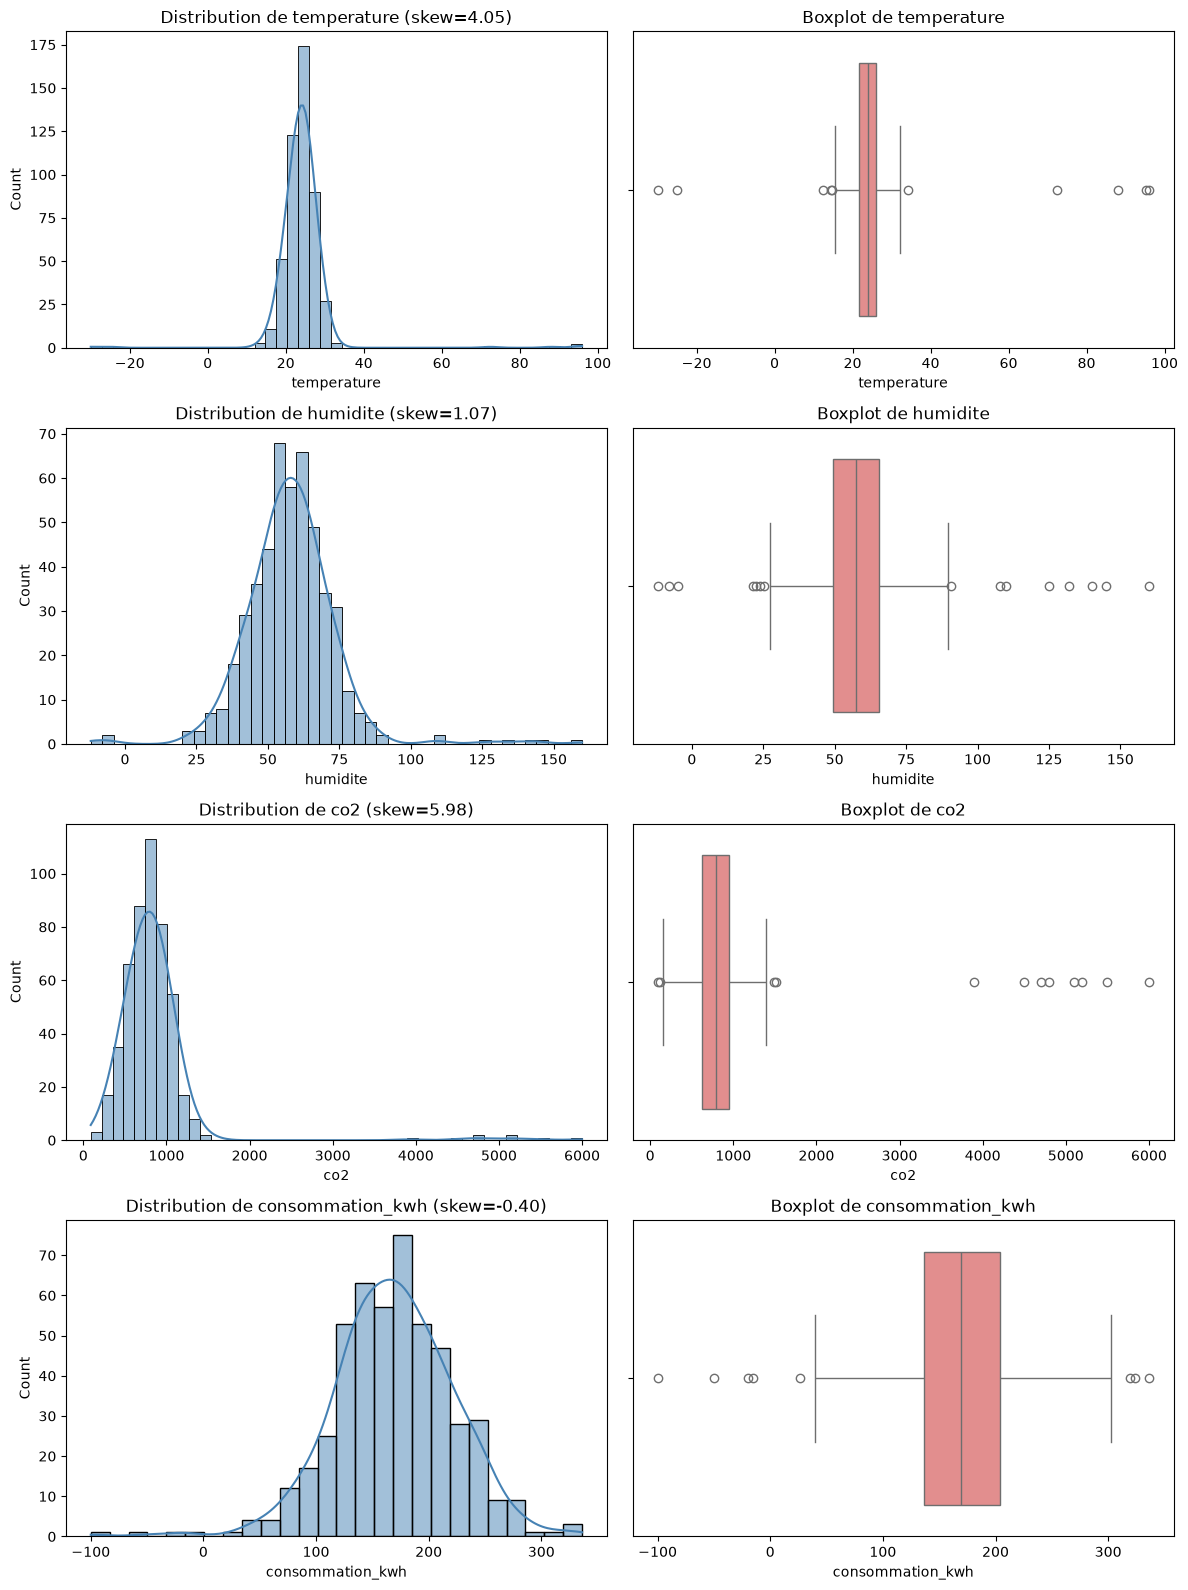

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_a_visualiser = ["temperature", "humidite", "co2", "consommation_kwh"]

fig, axes = plt.subplots(len(cols_a_visualiser), 2, figsize=(12, 4 * len(cols_a_visualiser)))
for i, col in enumerate(cols_a_visualiser):
    sns.histplot(df_clean[col].dropna(), kde=True, ax=axes[i, 0], color="steelblue")
    axes[i, 0].set_title(f"Distribution de {col} (skew={df_clean[col].skew():.2f})")
    sns.boxplot(x=df_clean[col], ax=axes[i, 1], color="lightcoral")
    axes[i, 1].set_title(f"Boxplot de {col}")



plt.tight_layout()
plt.show()

##### d) Détection chiffrée des valeurs aberrantes potentielles via la règle de l'IQR (1.5 x IQR)

In [90]:

def bornes_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

for col in cols_a_visualiser:
    borne_inf, borne_sup = bornes_iqr(df_clean[col].dropna())
    nb_outliers = ((df_clean[col] < borne_inf) | (df_clean[col] > borne_sup)).sum()
    print(f"{col} : bornes IQR = [{borne_inf:.1f} ; {borne_sup:.1f}] "
          f"-> {nb_outliers} valeurs potentiellement aberrantes "
          f"(asymétrie : {'oui' if abs(df_clean[col].skew()) > 0.5 else 'non'})")

temperature : bornes IQR = [15.0 ; 32.6] -> 10 valeurs potentiellement aberrantes (asymétrie : oui)
humidite : bornes IQR = [25.3 ; 89.8] -> 15 valeurs potentiellement aberrantes (asymétrie : oui)
co2 : bornes IQR = [132.0 ; 1444.0] -> 12 valeurs potentiellement aberrantes (asymétrie : oui)
consommation_kwh : bornes IQR = [35.1 ; 305.1] -> 8 valeurs potentiellement aberrantes (asymétrie : non)


#### 16) Quelle stratégie utiliser pour les valeurs aberrantes ?

Stratégie retenue pour les valeurs aberrantes restantes (après correction des incohérences
manifestes en Question 12):

- Capping / winsorisation via la règle de l'IQR : toute valeur en dehors de
  [Q1 - 1.5*IQR ; Q3 + 1.5*IQR] est ramenée à la borne la plus proche plutôt que supprimée,
  ce qui conserve l'observation (et les informations des autres colonnes) tout en limitant
  l'impact des valeurs extrêmes sur les modèles sensibles à l'échelle (ex : régression linéaire,
  KNN).
- On préfère cette approche à une suppression pure des lignes, qui ferait perdre des
  observations potentiellement informatives (une valeur extrême n'est pas forcément une erreur,
  cela peut être un vrai comportement rare comme un pic de consommation).

#### 17) Afficher la fréquence des :
a) bâtiments ;
b) types de bâtiments ;
c) modes de climatisation ;
d) états du système ;
e) classes alerte.

a) Fréquence de 'batiment' :
batiment
B1    92
B5    65
B7    64
B2    60
B4    58
B3    57
B8    53
B6    51
Name: count, dtype: int64 

b) Fréquence de 'type_batiment' :
type_batiment
Bureau               207
Centre commercial     64
École                 58
Hôpital               57
Entrepôt              52
Université            48
NaN                    4
ÉCOLE                  1
ecole                  1
BUREAU                 1
Bureu                  1
bureau                 1
 UNIVERSITÉ            1
hôpital                1
centre commercial      1
 Bureau                1
entrepot               1
Name: count, dtype: int64 

c) Fréquence de 'mode_climatisation' :
mode_climatisation
Normal     265
Eco        130
Boost       96
NaN          5
normal       1
BOOST        1
normale      1
Normal       1
Name: count, dtype: int64 

d) Fréquence de 'etat_systeme' :
etat_systeme
Normal    436
Alerte     52
Panne      12
Name: count, dtype: int64 

e) Fréquence de 'alerte' :
alerte
Non  

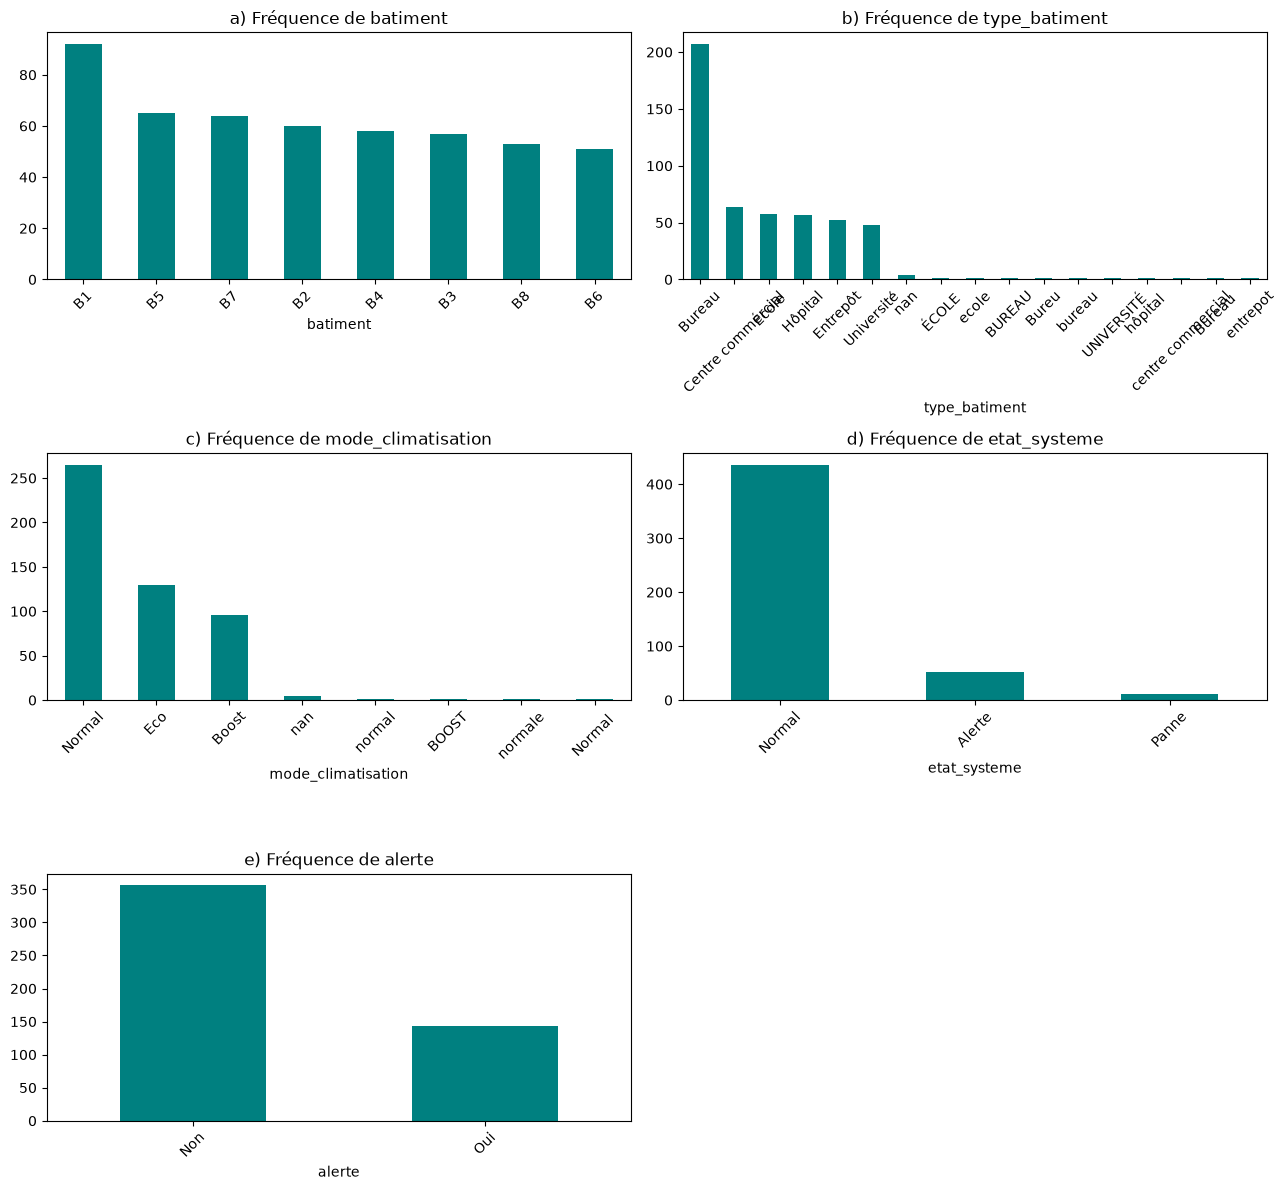

In [91]:
cols_frequence = {
    "a": "batiment",
    "b": "type_batiment",
    "c": "mode_climatisation",
    "d": "etat_systeme",
    "e": "alerte",
}

fig, axes = plt.subplots(3, 2, figsize=(13, 12))
axes = axes.flatten()
for ax, (lettre, col) in zip(axes, cols_frequence.items()):
    counts = df_clean[col].value_counts(dropna=False)
    print(f"{lettre}) Fréquence de '{col}' :")
    print(counts, "\n")
    counts.plot(kind="bar", ax=ax, color="teal")
    ax.set_title(f"{lettre}) Fréquence de {col}")
    ax.tick_params(axis="x", rotation=45)
axes[-1].axis("off")
plt.tight_layout()
plt.show()

#### 18) Y a-t-il un déséquilibre des classes sur la variable « alerte » ?

In [93]:
repartition_alerte = df_clean["alerte"].value_counts(normalize=True) * 100
print("Répartition des classes de 'alerte' (%) :")
print(repartition_alerte.round(2))

ratio = repartition_alerte.max() / repartition_alerte.min()
print(f"\nRatio classe majoritaire sur classe minoritaire : {ratio:.2f}")
print("-> Il y a un déséquilibre des classes" if ratio > 1.5 else "-> Les classes sont globalement équilibrées",
      "(seuil indicatif : ratio > 1.5).")


Répartition des classes de 'alerte' (%) :
alerte
Non    71.2
Oui    28.8
Name: proportion, dtype: float64

Ratio classe majoritaire sur classe minoritaire : 2.47
-> Il y a un déséquilibre des classes (seuil indicatif : ratio > 1.5).


#### 19) Corrélation entre variables numériques

a) On visualise la matrice de corrélation avec seaborn (heatmap). b) On identifie les corrélations positives, négatives et les variables faiblement corrélées.

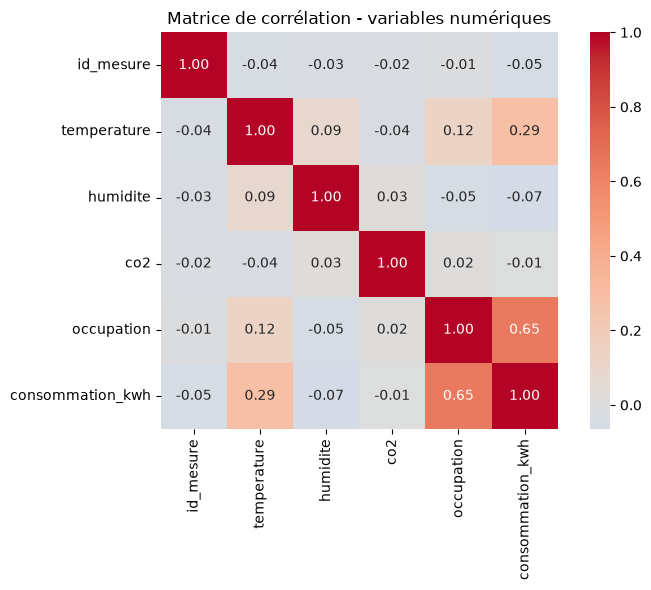

In [94]:
# a) Matrice de corrélation (Pearson) sur les variables numériques
corr = df_clean[variables_numeriques].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matrice de corrélation - variables numériques")
plt.tight_layout()
plt.show()

In [95]:
# b) Identification des paires les plus (positivement / négativement) corrélées,
#    et des variables faiblement corrélées entre elles
corr_pairs = corr.where(~np.eye(len(corr), dtype=bool)).stack().sort_values(ascending=False)
# on ne garde qu'une occurrence par paire (i,j) et (j,i) sont identiques
corr_pairs = corr_pairs[~corr_pairs.index.duplicated()]

print("Corrélations les plus positives :")
print(corr_pairs.head(3))

print("\nCorrélations les plus négatives :")
print(corr_pairs.tail(3))

print("\nVariables faiblement corrélées (|corr| < 0.2) :")
faibles = corr_pairs[corr_pairs.abs() < 0.2]
print(faibles if len(faibles) > 0 else "Aucune paire sous ce seuil.")

Corrélations les plus positives :
consommation_kwh  occupation          0.645469
occupation        consommation_kwh    0.645469
consommation_kwh  temperature         0.286609
dtype: float64

Corrélations les plus négatives :
co2               co2                NaN
occupation        occupation         NaN
consommation_kwh  consommation_kwh   NaN
dtype: float64

Variables faiblement corrélées (|corr| < 0.2) :
temperature       occupation          0.118121
occupation        temperature         0.118121
temperature       humidite            0.088543
humidite          temperature         0.088543
co2               humidite            0.025466
humidite          co2                 0.025466
occupation        co2                 0.016771
co2               occupation          0.016771
consommation_kwh  co2                -0.006126
co2               consommation_kwh   -0.006126
id_mesure         occupation         -0.014759
occupation        id_mesure          -0.014759
co2               id_mes

# Partie 2 — Séparation X / y

#### 1) Définir la variable "alerte" comme la cible y

In [96]:
y = df_clean["alerte"].copy()
print("Cible y définie : 'alerte'")
y.value_counts()

Cible y définie : 'alerte'


alerte
Non    356
Oui    144
Name: count, dtype: int64

#### 2)Trouver des variables explicatives X pertinentes

In [99]:
colonnes_a_exclure = ["id_mesure", "date", "etat_systeme", "alerte"]
X = df_clean.drop(columns=colonnes_a_exclure)

print("Variables explicatives retenues dans X :")
print(X.columns.tolist())
print("\nShape de X :", X.shape)

Variables explicatives retenues dans X :
['batiment', 'type_batiment', 'zone', 'temperature', 'humidite', 'co2', 'occupation', 'consommation_kwh', 'mode_climatisation', 'jour_semaine']

Shape de X : (500, 10)


#### 3)Afficher les cinq premières lignes de X ainsi que de y

In [100]:
print("=== X (5 premières lignes) ===")
display(X.head())
print("\n=== y (5 premières valeurs) ===")
display(y.head())

=== X (5 premières lignes) ===


,batiment,type_batiment,zone,temperature,humidite,co2,occupation,consommation_kwh,mode_climatisation,jour_semaine
0,B8,Entrepôt,A,23.0,40.0,851.0,26.0,138.4,Eco,Jeudi
1,B7,Bureau,D,28.0,69.0,538.0,0.0,170.2,Eco,Lundi
2,B5,Centre commercial,B,19.5,52.3,1198.0,64.0,149.8,Normal,Dimanche
3,B6,Université,D,20.0,58.4,1014.0,30.0,141.6,Normal,Dimanche
4,B7,Bureau,D,26.8,70.5,628.0,42.0,228.3,Normal,Jeudi



=== y (5 premières valeurs) ===


0    Non
1    Non
2    Oui
3    Non
4    Non
Name: alerte, dtype: str

# Partie 3 — Découpage Train/Test

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,      # reproductibilité du découpage
    stratify=y,            # conserve les proportions de classes de 'alerte'
)

print("X_train :", X_train.shape, " | X_test :", X_test.shape)
print("y_train :", y_train.shape, " | y_test :", y_test.shape)

print("\nProportions dans y (données d'origine) :")
print(y.value_counts(normalize=True).round(3))
print("\nProportions dans y_train :")
print(y_train.value_counts(normalize=True).round(3))
print("\nProportions dans y_test :")
print(y_test.value_counts(normalize=True).round(3))

X_train : (400, 10)  | X_test : (100, 10)
y_train : (400,)  | y_test : (100,)

Proportions dans y (données d'origine) :
alerte
Non    0.712
Oui    0.288
Name: proportion, dtype: float64

Proportions dans y_train :
alerte
Non    0.712
Oui    0.288
Name: proportion, dtype: float64

Proportions dans y_test :
alerte
Non    0.71
Oui    0.29
Name: proportion, dtype: float64


# Partie 4 — Encodage des variables catégorielles

On choisit, pour chaque variable catégorielle de X, l'encodage le plus adapté :

| Variable | Cardinalité | Nature | Encodage retenu | Justification |
|---|---|---|---|---|
| `batiment` | 8 modalités (B1..B8) | nominale, pas d'ordre | One-Hot Encoding | Pas d'ordre naturel entre les bâtiments ; cardinalité faible -> pas d'explosion dimensionnelle |
| `type_batiment` | 6 modalités | nominale, pas d'ordre | One-Hot Encoding | Idem : catégories sans relation d'ordre |
| `zone` | 4 modalités (A..D) | nominale, pas d'ordre | One-Hot Encoding | Zones géographiques/fonctionnelles sans hiérarchie |
| `mode_climatisation` | 3 modalités (Eco/Normal/Boost) | **ordinale** (intensité croissante) | Ordinal Encoding | Il existe un ordre logique d'intensité Eco < Normal < Boost, qu'un One-Hot ferait perdre |
| `jour_semaine` | 7 modalités | nominale (ou cyclique) | One-Hot Encoding | Pas d'ordre linéaire pertinent pour un modèle non cyclique simple |



In [102]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# --- Illustration du choix d'encodage sur un extrait de X_train ---

# Variable ordinale : mode_climatisation (Eco < Normal < Boost)
ordre_climatisation = [["Eco", "Normal", "Boost"]]
ordinal_encoder_demo = OrdinalEncoder(categories=ordre_climatisation,
                                        handle_unknown="use_encoded_value", unknown_value=-1)

# Variables nominales : One-Hot Encoding
colonnes_onehot = ["batiment", "type_batiment", "zone", "jour_semaine"]
onehot_encoder_demo = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

apercu = X_train[["mode_climatisation"] + colonnes_onehot].dropna().head(5)
print("Avant encodage :")
display(apercu)

print("\nAprès Ordinal Encoding de 'mode_climatisation' :")
print(ordinal_encoder_demo.fit_transform(apercu[["mode_climatisation"]]).ravel())

print("\nAprès One-Hot Encoding des variables nominales (aperçu des colonnes générées) :")
onehot_demo = onehot_encoder_demo.fit_transform(apercu[colonnes_onehot])
print(onehot_encoder_demo.get_feature_names_out(colonnes_onehot))

Avant encodage :


,mode_climatisation,batiment,type_batiment,zone,jour_semaine
263,Normal,B6,Université,B,Samedi
148,Boost,B1,Bureau,B,Mercredi
5,Eco,B3,Hôpital,D,Lundi
66,Normal,B8,Entrepôt,A,Jeudi
451,Normal,B3,Hôpital,D,Dimanche



Après Ordinal Encoding de 'mode_climatisation' :
[1. 2. 0. 1. 1.]

Après One-Hot Encoding des variables nominales (aperçu des colonnes générées) :
['batiment_B1' 'batiment_B3' 'batiment_B6' 'batiment_B8'
 'type_batiment_Bureau' 'type_batiment_Entrepôt' 'type_batiment_Hôpital'
 'type_batiment_Université' 'zone_A' 'zone_B' 'zone_D'
 'jour_semaine_Dimanche' 'jour_semaine_Jeudi' 'jour_semaine_Lundi'
 'jour_semaine_Mercredi' 'jour_semaine_Samedi']


# Partie 5 — Mise à l'échelle

#### 1) A l’aide de quelques variables, justifier la pertinence de la mise à l’échelle

In [103]:
apercu_echelles = X_train[["temperature", "humidite", "co2", "consommation_kwh"]].describe().T[
    ["min", "max", "mean", "std"]]
apercu_echelles

,min,max,mean,std
temperature,-25.0,96.0,24.331714,7.720520
humidite,-12.0,160.0,57.791071,15.864756
co2,89.0,6000.0,838.164975,558.102912
consommation_kwh,-100.0,336.2,168.279798,55.492897


Constat : 'co2' varie sur une échelle de plusieurs centaines/milliers (ex. ~100 à ~2000+),
alors que 'temperature' varie entre environ -10 et 45. Sans mise à l'échelle, les algorithmes
sensibles aux distances ou aux gradients (régression logistique, SVM, KNN, réseaux de neurones,
PCA...) donneraient artificiellement beaucoup plus de poids à 'co2' qu'à 'temperature', alors
que ce n'est pas justifié sur le plan métier. La mise à l'échelle est donc pertinente pour
ramener toutes les variables numériques à un ordre de grandeur comparable.

#### 2) Appliquer et justifier une technique de mise à l'échelle

On choisit le **StandardScaler** (centrage-réduction : moyenne 0, écart-type 1) plutôt qu'un Min-Max scaling, car les variables numériques (température, humidité, CO₂, consommation) ne sont pas bornées de façon stricte et peuvent encore contenir quelques valeurs extrêmes malgré le nettoyage : le StandardScaler y est moins sensible qu'un Min-Max, qui écraserait toute la distribution si une seule valeur extrême subsistait.

In [104]:
from sklearn.preprocessing import StandardScaler

scaler_demo = StandardScaler()
colonnes_numeriques = ["temperature", "humidite", "co2", "occupation", "consommation_kwh"]

# Démonstration (le fit définitif se fera dans le pipeline, Partie 6, sur X_train uniquement)
apercu_scaled = scaler_demo.fit_transform(X_train[colonnes_numeriques].dropna())
print("Moyennes après mise à l'échelle (doivent être ~0) :", apercu_scaled.mean(axis=0).round(3))
print("Écarts-types après mise à l'échelle (doivent être ~1) :", apercu_scaled.std(axis=0).round(3))

Moyennes après mise à l'échelle (doivent être ~0) : [-0.  0. -0. -0.  0.]
Écarts-types après mise à l'échelle (doivent être ~1) : [1. 1. 1. 1. 1.]


#### 3) Pourquoi ne doit-on pas calculer la moyenne et l'écart-type à partir du dataset complet ?

Si on calcule la moyenne et l'écart-type sur l'ensemble complet du dataset (train + test) avant de faire le split, les statistiques utilisées pour standardiser le jeu d'entraînement auraient 'vu' des informations issues du jeu de test. Le modèle bénéficierait indirectement d'une information qu'il ne devrait pas avoir au moment de l'entraînement : c'est une fuite de données(data leakage). Cela conduit à une évaluation optimiste et biaisée des performances du modèle,qui ne se reproduira pas sur de vraies données futures.

La bonne pratique est donc de calculer (fit) la moyenne et l'écart-type UNIQUEMENT sur X_train,puis d'appliquer (transform) ces mêmes statistiques à X_train et à X_test. 